> ⚠️ **Note:** This model was trained in Google Colab with GPU Support (TensorFlow 2.18).  
> Only the weights were saved (`.weights.h5`) to prevent compatibility issues when loading the model in environments like VS Code.  
> Ensure you use the same architecture when loading weights locally.


In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.28G/2.29G [00:22<00:00, 248MB/s]
100% 2.29G/2.29G [00:22<00:00, 109MB/s]


In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/chest-xray-pneumonia.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [6]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

In [7]:
train_path = '/content/chest_xray/train'
test_path = '/content/chest_xray/test'

IMG_SIZE = 224
BATCH_SIZE = 32

In [8]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.1
)
test_gen =ImageDataGenerator(
    rescale=1./255
)

In [16]:
# Load datasets with grayscale images

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

val_data = train_gen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 4695 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 521 images belonging to 2 classes.


In [10]:
# CLASS WEIGHTS
y_train = train_data.classes
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(weights)}

In [12]:
# MODEL SETUP
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [13]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
# CALLBACKS
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'xray_model.weights.h5',
    save_weights_only=True,
    save_best_only=True
)

In [17]:
# TRAIN
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stopping, checkpoint],
    class_weight=class_weights
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 121s 742ms/step - accuracy: 0.7975 - loss: 0.4357 - val_accuracy: 0.9060 - val_loss: 0.2164
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 98s 662ms/step - accuracy: 0.9281 - loss: 0.1834 - val_accuracy: 0.8848 - val_loss: 0.2578
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 99s 672ms/step - accuracy: 0.9322 - loss: 0.1711 - val_accuracy: 0.9347 - val_loss: 0.1870
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 97s 655ms/step - accuracy: 0.9363 - loss: 0.1665 - val_accuracy: 0.9405 - val_loss: 0.1511
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 97s 657ms/step - accuracy: 0.9411 - loss: 0.1536 - val_accuracy: 0.9424 - val_loss: 0.1421
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 96s 656ms/step - accuracy: 0.9456 - loss: 0.1442 - val_accuracy: 0.9367 - val_loss: 0.1444
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 97s 659ms/step - accuracy: 0.9442 - loss: 0.1418 - val_accuracy: 0.9251 - val_loss: 0.1570
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 97s 658ms/step - accuracy: 0.9524 - loss: 

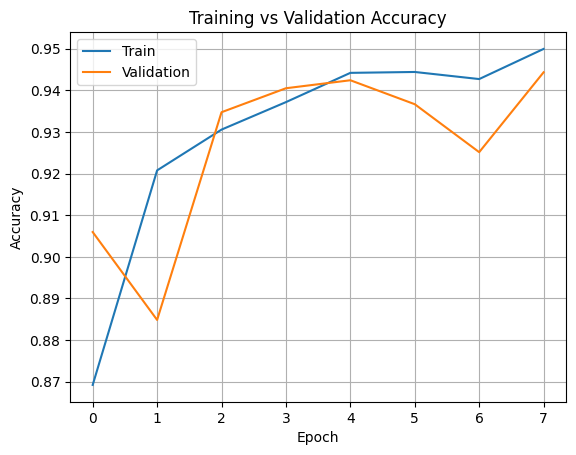

In [18]:
# PLOT ACCURACY
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.title('Training vs Validation Accuracy')
plt.show()


Text(0, 0.5, 'Loss')

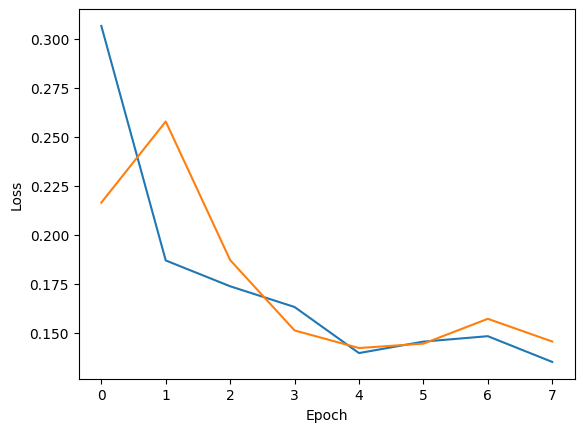

In [19]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [21]:
# Training  ACCURACY
train_acc = history.history['accuracy'][-1]
print(f"✅ Final Training Accuracy: {train_acc * 100:.2f}%")

# TEST ACCURACY
test_loss, test_acc = model.evaluate(test_data, verbose=0)
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")


✅ Final Training Accuracy: 94.99%
✅ Test Accuracy: 90.22%


### Saving Weights to use it in vs code for avoiding version mismatch

In [23]:
from google.colab import files
files.download('xray_model.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Testing an image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


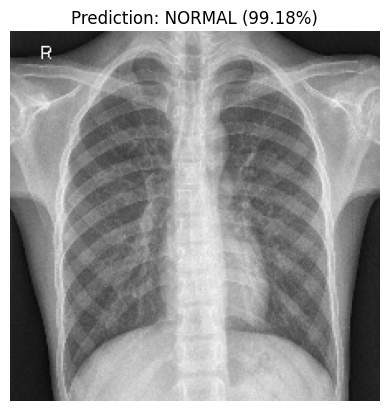

In [33]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
model.load_weights('xray_model.weights.h5')
img_path = "/content/chest_xray/test/NORMAL/IM-0005-0001.jpeg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

label = "PNEUMONIA" if prediction > 0.5 else "NORMAL"
confidence = prediction if prediction > 0.5 else 1 - prediction

plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {label} ({confidence * 100:.2f}%)")
plt.show()